In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bluestock Mutual Fund Analytics")
print("Performance Analytics")
print("=" * 60)

Bluestock Mutual Fund Analytics
Performance Analytics


In [2]:
# Load cleaned NAV data
nav = pd.read_csv("../data/processed/clean_nav.csv")

# Load cleaned performance data
performance = pd.read_csv("../data/processed/clean_performance.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

print("NAV data:", nav.shape)
print("Performance data:", performance.shape)
print("Unique funds:", nav["amfi_code"].nunique())
print("NAV date range:", nav["date"].min(), "to", nav["date"].max())

NAV data: (46000, 3)
Performance data: (40, 19)
Unique funds: 40
NAV date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [3]:
# Sort NAV data by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Check the result
print(nav.head(10))
print()
print("Missing daily returns:", nav["daily_return"].isna().sum())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073

Missing daily returns: 40


In [4]:
# Calculate annualized return for each fund

annualized_returns = (
    nav.groupby("amfi_code")["daily_return"]
    .mean() * 252
)

annualized_returns = annualized_returns * 100

print("Annualized Return (%)")
print(annualized_returns.head(10))

Annualized Return (%)
amfi_code
100016     3.568303
100025     4.285356
100033    27.211057
101206    21.464662
101207    10.696212
101208     6.086966
102885    16.988801
102886     2.767331
102887    16.262585
118632    21.803695
Name: daily_return, dtype: float64


In [5]:
# Calculate CAGR for each fund

def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100


cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")
    
    end_date = group["date"].max()
    end_nav = group.iloc[-1]["nav"]
    
    result = {"amfi_code": amfi_code}
    
    for years in [1, 3, 5]:
        start_date = end_date - pd.DateOffset(years=years)
        
        available = group[group["date"] >= start_date]
        
        if len(available) > 0:
            start_nav = available.iloc[0]["nav"]
            actual_days = (end_date - available.iloc[0]["date"]).days
            actual_years = actual_days / 365.25
            
            if actual_years > 0:
                result[f"cagr_{years}yr_pct"] = (
                    (end_nav / start_nav) ** (1 / actual_years) - 1
                ) * 100
            else:
                result[f"cagr_{years}yr_pct"] = np.nan
        else:
            result[f"cagr_{years}yr_pct"] = np.nan
    
    cagr_results.append(result)

cagr = pd.DataFrame(cagr_results)

print(cagr.head(10))

   amfi_code  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0     100016     -2.225777      1.292353      2.637074
1     100025      3.707553      3.915479      4.458210
2     100033     53.277195     32.433971     30.123153
3     101206     47.963794     28.960211     23.538361
4     101207    -24.000309     -4.151454      7.938765
5     101208      7.241777      6.314299      6.509027
6     102885     20.222859     19.662361     18.232379
7     102886    -16.807960     -0.767232      1.171745
8     102887     13.593044     25.549670     16.841120
9     118632     34.007896     22.646647     24.049493


In [6]:
# Calculate Sharpe Ratio using 6.5% annual risk-free rate

risk_free_rate = 0.065

sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    
    average_daily_return = returns.mean()
    daily_std = returns.std()
    
    if daily_std != 0:
        daily_rf = (1 + risk_free_rate) ** (1 / 252) - 1
        sharpe = ((average_daily_return - daily_rf) / daily_std) * np.sqrt(252)
    else:
        sharpe = np.nan
    
    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio_calculated": sharpe
    })

sharpe = pd.DataFrame(sharpe_results)

print(sharpe.head(10))
print()
print("Number of funds:", len(sharpe))

   amfi_code  sharpe_ratio_calculated
0     100016                -0.187650
1     100025                -0.515438
2     100033                 1.104352
3     101206                 1.041061
4     101207                 0.170481
5     101208                -0.417229
6     102885                 0.832815
7     102886                -0.194707
8     102887                 0.632319
9     118632                 1.095918

Number of funds: 40


In [7]:
# Calculate Sortino Ratio using 6.5% annual risk-free rate

risk_free_rate = 0.065

sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    
    daily_rf = (1 + risk_free_rate) ** (1 / 252) - 1
    
    excess_returns = returns - daily_rf
    
    downside_returns = excess_returns[excess_returns < 0]
    
    downside_deviation = np.sqrt(np.mean(downside_returns ** 2))
    
    if downside_deviation != 0:
        sortino = (excess_returns.mean() / downside_deviation) * np.sqrt(252)
    else:
        sortino = np.nan
    
    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino
    })

sortino = pd.DataFrame(sortino_results)

print(sortino.head(10))
print()
print("Number of funds:", len(sortino))

   amfi_code  sortino_ratio
0     100016      -0.191590
1     100025      -0.515918
2     100033       1.133525
3     101206       1.084557
4     101207       0.173543
5     101208      -0.407411
6     102885       0.858129
7     102886      -0.190719
8     102887       0.660905
9     118632       1.120520

Number of funds: 40


In [8]:
# Load benchmark data
benchmark = pd.read_csv("../data/raw/1788499982615-f9647ab2-10_benchmark_indices.csv")

# Convert date column
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Benchmark data:", benchmark.shape)
print("Indices:", benchmark["index_name"].unique())
print("Date range:", benchmark["date"].min(), "to", benchmark["date"].max())

Benchmark data: (8050, 3)
Indices: <StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [9]:
# Select Nifty 100 data
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate daily return
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty100.head(10))
print()
print("Nifty 100 records:", len(nifty100))
print("Missing returns:", nifty100["benchmark_return"].isna().sum())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150
1155 2022-01-10   NIFTY100     17516.51         -0.008351
1156 2022-01-11   NIFTY100     17603.08          0.004942
1157 2022-01-12   NIFTY100     17763.76          0.009128
1158 2022-01-13   NIFTY100     17830.30          0.003746
1159 2022-01-14   NIFTY100     17578.93         -0.014098

Nifty 100 records: 1150
Missing returns: 1


In [10]:
# Calculate Alpha and Beta against Nifty 100 using OLS

from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, fund_group in nav.groupby("amfi_code"):
    
    # Select fund returns
    fund_returns = fund_group[["date", "daily_return"]].dropna()
    
    # Merge with Nifty 100 returns
    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()
    
    if len(merged) > 1:
        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
        
        beta = regression.slope
        daily_alpha = regression.intercept
        
        # Convert daily alpha to annual alpha
        annual_alpha = ((1 + daily_alpha) ** 252 - 1) * 100
        
    else:
        beta = np.nan
        annual_alpha = np.nan
    
    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha_pct": annual_alpha,
        "beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

print(alpha_beta.head(10))
print()
print("Number of funds:", len(alpha_beta))

   amfi_code  alpha_pct      beta
0     100016   3.818399 -0.058268
1     100025   4.374404  0.001158
2     100033  31.233357  0.005104
3     101206  23.850751  0.021086
4     101207  11.510366 -0.065289
5     101208   6.274386  0.000267
6     102885  18.581455 -0.019487
7     102886   2.939138 -0.042125
8     102887  17.593132  0.016683
9     118632  24.383517 -0.008354

Number of funds: 40


In [11]:
# Calculate Maximum Drawdown for each fund

drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    
    group = group.sort_values("date").copy()
    
    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()
    
    # Drawdown
    group["drawdown"] = (
        (group["nav"] - group["running_max"])
        / group["running_max"]
    )
    
    # Maximum drawdown
    max_drawdown = group["drawdown"].min() * 100
    
    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_drawdown
    })

max_drawdown = pd.DataFrame(drawdown_results)

print(max_drawdown.head(10))
print()
print("Number of funds:", len(max_drawdown))

   amfi_code  max_drawdown_pct
0     100016        -24.734441
1     100025         -4.308264
2     100033        -16.217209
3     101206        -11.291596
4     101207        -35.446916
5     101208         -0.162250
6     102885        -10.859862
7     102886        -28.001124
8     102887        -21.539827
9     118632        -17.414075

Number of funds: 40


In [12]:
# Combine all performance metrics into one table

performance_analysis = (
    performance[["amfi_code", "expense_ratio_pct"]]
    .merge(cagr, on="amfi_code", how="left")
    .merge(sharpe, on="amfi_code", how="left")
    .merge(sortino, on="amfi_code", how="left")
    .merge(alpha_beta, on="amfi_code", how="left")
    .merge(max_drawdown, on="amfi_code", how="left")
)

# Add annualized return
performance_analysis = performance_analysis.merge(
    annualized_returns.rename("annualized_return_pct"),
    on="amfi_code",
    how="left"
)

print(performance_analysis.head(10))
print()
print("Rows:", len(performance_analysis))
print("Columns:", len(performance_analysis.columns))

   amfi_code  expense_ratio_pct  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct  \
0     119551               1.54     60.489297     30.448613     25.804686   
1     119552               0.66      5.710118     16.263375     21.524236   
2     119598               1.43     82.851575     26.663091     32.423536   
3     119599               0.72     13.957994     -1.337084      2.054485   
4     119120               0.77      5.525880      5.838988      5.889419   
5     100016               1.55     -2.225777      1.292353      2.637074   
6     125497               0.92     28.697580     18.429918     19.017795   
7     100033               1.38     53.277195     32.433971     30.123153   
8     125498               0.78     15.455077     11.242519     11.301817   
9     100025               0.56      3.707553      3.915479      4.458210   

   sharpe_ratio_calculated  sortino_ratio  alpha_pct      beta  \
0                 1.222947       1.277845  26.099783 -0.031751   
1                 0.

In [13]:
# Create 0-100 Fund Scorecard

def min_max_score(series):
    min_value = series.min()
    max_value = series.max()
    
    if max_value == min_value:
        return pd.Series(100, index=series.index)
    
    return ((series - min_value) / (max_value - min_value)) * 100


# Higher is better
performance_analysis["return_score"] = min_max_score(
    performance_analysis["cagr_3yr_pct"]
)

performance_analysis["sharpe_score"] = min_max_score(
    performance_analysis["sharpe_ratio_calculated"]
)

performance_analysis["alpha_score"] = min_max_score(
    performance_analysis["alpha_pct"]
)


# Lower is better, so reverse the score
performance_analysis["expense_score"] = 100 - min_max_score(
    performance_analysis["expense_ratio_pct"]
)

performance_analysis["drawdown_score"] = 100 - min_max_score(
    performance_analysis["max_drawdown_pct"]
)


# Apply required weights
performance_analysis["fund_score"] = (
    performance_analysis["return_score"] * 0.30
    + performance_analysis["sharpe_score"] * 0.25
    + performance_analysis["alpha_score"] * 0.20
    + performance_analysis["expense_score"] * 0.15
    + performance_analysis["drawdown_score"] * 0.10
)


# Round the final score
performance_analysis["fund_score"] = (
    performance_analysis["fund_score"].round(2)
)

print(
    performance_analysis[
        [
            "amfi_code",
            "cagr_3yr_pct",
            "sharpe_ratio_calculated",
            "alpha_pct",
            "expense_ratio_pct",
            "max_drawdown_pct",
            "fund_score"
        ]
    ].head(10)
)

   amfi_code  cagr_3yr_pct  sharpe_ratio_calculated  alpha_pct  \
0     119551     30.448613                 1.222947  26.099783   
1     119552     16.263375                 0.967752  21.970339   
2     119598     26.663091                 0.953332  35.416793   
3     119599     -1.337084                -0.049101   5.003079   
4     119120      5.838988                -0.175723   5.781206   
5     100016      1.292353                -0.187650   3.818399   
6     125497     18.429918                 0.789543  19.391188   
7     100033     32.433971                 1.104352  31.233357   
8     125498     11.242519                 0.311604  12.734183   
9     100025      3.915479                -0.515438   4.374404   

   expense_ratio_pct  max_drawdown_pct  fund_score  
0               1.54        -15.012385       67.47  
1               0.66        -11.803494       64.11  
2               1.43        -28.706006       71.50  
3               0.72        -52.574221       36.47  
4       

In [16]:
# Add fund names to the scorecard

fund_names = funds[["amfi_code", "scheme_name", "fund_house"]]

performance_analysis = performance_analysis.merge(
    fund_names,
    on="amfi_code",
    how="left"
)

# Show the fund name and score
scorecard = performance_analysis[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "cagr_3yr_pct",
        "sharpe_ratio_calculated",
        "alpha_pct",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "fund_score"
    ]
]

print(scorecard.head(10))

NameError: name 'funds' is not defined

In [17]:
# Load fund master data

funds = pd.read_csv(
    "../data/raw/1788499983024-b042c300-01_fund_master.csv"
)

print("Fund master:", funds.shape)
print(funds[["amfi_code", "scheme_name", "fund_house"]].head())

Fund master: (40, 15)
   amfi_code                                   scheme_name       fund_house
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund


In [18]:
# Add fund names to the scorecard

fund_names = funds[["amfi_code", "scheme_name", "fund_house"]]

performance_analysis = performance_analysis.merge(
    fund_names,
    on="amfi_code",
    how="left"
)

scorecard = performance_analysis[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "cagr_3yr_pct",
        "sharpe_ratio_calculated",
        "alpha_pct",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "fund_score"
    ]
]

print(scorecard.head(10))

   amfi_code                                        scheme_name  \
0     119551          SBI Bluechip Fund - Regular Plan - Growth   
1     119552           SBI Bluechip Fund - Direct Plan - Growth   
2     119598         SBI Small Cap Fund - Regular Plan - Growth   
3     119599          SBI Small Cap Fund - Direct Plan - Growth   
4     119120       SBI Magnum Gilt Fund - Regular Plan - Growth   
5     100016          HDFC Top 100 Fund - Regular Plan - Growth   
6     125497           HDFC Top 100 Fund - Direct Plan - Growth   
7     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
8     125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth   
9     100025       HDFC Short Term Debt Fund - Regular - Growth   

         fund_house  cagr_3yr_pct  sharpe_ratio_calculated  alpha_pct  \
0   SBI Mutual Fund     30.448613                 1.222947  26.099783   
1   SBI Mutual Fund     16.263375                 0.967752  21.970339   
2   SBI Mutual Fund     26.663091          

In [19]:
# Check the final scorecard

print("Total funds:", len(scorecard))
print("Missing scores:", scorecard["fund_score"].isna().sum())
print()
print("Score range:")
print("Minimum:", scorecard["fund_score"].min())
print("Maximum:", scorecard["fund_score"].max())

Total funds: 40
Missing scores: 0

Score range:
Minimum: 18.17
Maximum: 76.15


In [20]:
# Sort funds by score

scorecard_sorted = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

print(
    scorecard_sorted[
        [
            "scheme_name",
            "fund_house",
            "cagr_3yr_pct",
            "sharpe_ratio_calculated",
            "alpha_pct",
            "expense_ratio_pct",
            "max_drawdown_pct",
            "fund_score"
        ]
    ].to_string(index=False)
)

                                          scheme_name               fund_house  cagr_3yr_pct  sharpe_ratio_calculated  alpha_pct  expense_ratio_pct  max_drawdown_pct  fund_score
        Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF     33.991970                 1.462504  30.956255               1.46        -11.265729       76.15
             ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF     31.769243                 1.190559  33.972726               1.36        -18.188514       75.84
            ICICI Pru Bluechip Fund - Direct - Growth      ICICI Prudential MF     32.478927                 1.040569  23.597383               0.80        -12.588276       74.65
                  Axis Midcap Fund - Regular - Growth         Axis Mutual Fund     35.102528                 1.008626  29.774983               1.38        -20.960884       73.34
   HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund     32.433971                 1

In [21]:
# Select Nifty 50 data
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

# Sort by date
nifty50 = nifty50.sort_values("date")

# Calculate daily return
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

print(nifty50.head(10))
print()
print("Nifty 50 records:", len(nifty50))
print("Missing returns:", nifty50["benchmark_return"].isna().sum())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676
5 2022-01-10    NIFTY50     18124.84          0.020592
6 2022-01-11    NIFTY50     18256.96          0.007289
7 2022-01-12    NIFTY50     18162.54         -0.005172
8 2022-01-13    NIFTY50     18179.05          0.000909
9 2022-01-14    NIFTY50     17971.75         -0.011403

Nifty 50 records: 1150
Missing returns: 1


In [22]:
# Calculate tracking error against Nifty 50 and Nifty 100

tracking_results = []

for amfi_code, fund_group in nav.groupby("amfi_code"):
    
    fund_returns = fund_group[["date", "daily_return"]].dropna()
    
    # Merge with Nifty 50
    merged_50 = pd.merge(
        fund_returns,
        nifty50[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()
    
    # Merge with Nifty 100
    merged_100 = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()
    
    # Tracking error
    tracking_error_50 = (
        merged_50["daily_return"] - merged_50["benchmark_return"]
    ).std() * np.sqrt(252) * 100
    
    tracking_error_100 = (
        merged_100["daily_return"] - merged_100["benchmark_return"]
    ).std() * np.sqrt(252) * 100
    
    tracking_results.append({
        "amfi_code": amfi_code,
        "tracking_error_nifty50_pct": tracking_error_50,
        "tracking_error_nifty100_pct": tracking_error_100
    })

tracking_error = pd.DataFrame(tracking_results)

print(tracking_error.head(10))
print()
print("Number of funds:", len(tracking_error))

   amfi_code  tracking_error_nifty50_pct  tracking_error_nifty100_pct
0     100016                   19.641644                    19.928360
1     100025                   13.644549                    13.453514
2     100033                   22.975511                    22.869942
3     101206                   19.146864                    19.270641
4     101207                   29.169994                    29.211743
5     101208                   12.860150                    12.895689
6     102885                   18.192566                    18.368034
7     102886                   22.688898                    22.560814
8     102887                   20.015215                    20.221623
9     118632                   18.806323                    19.211519

Number of funds: 40


In [23]:
# Add tracking error to the scorecard

scorecard_final = scorecard.merge(
    tracking_error,
    on="amfi_code",
    how="left"
)

print(
    scorecard_final[
        [
            "scheme_name",
            "fund_house",
            "fund_score",
            "tracking_error_nifty50_pct",
            "tracking_error_nifty100_pct"
        ]
    ].head(10)
)

print()
print("Total funds:", len(scorecard_final))
print(
    "Missing Nifty 50 tracking errors:",
    scorecard_final["tracking_error_nifty50_pct"].isna().sum()
)
print(
    "Missing Nifty 100 tracking errors:",
    scorecard_final["tracking_error_nifty100_pct"].isna().sum()
)

                                         scheme_name        fund_house  \
0          SBI Bluechip Fund - Regular Plan - Growth   SBI Mutual Fund   
1           SBI Bluechip Fund - Direct Plan - Growth   SBI Mutual Fund   
2         SBI Small Cap Fund - Regular Plan - Growth   SBI Mutual Fund   
3          SBI Small Cap Fund - Direct Plan - Growth   SBI Mutual Fund   
4       SBI Magnum Gilt Fund - Regular Plan - Growth   SBI Mutual Fund   
5          HDFC Top 100 Fund - Regular Plan - Growth  HDFC Mutual Fund   
6           HDFC Top 100 Fund - Direct Plan - Growth  HDFC Mutual Fund   
7  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  HDFC Mutual Fund   
8  HDFC Mid-Cap Opportunities Fund - Direct - Growth  HDFC Mutual Fund   
9       HDFC Short Term Debt Fund - Regular - Growth  HDFC Mutual Fund   

   fund_score  tracking_error_nifty50_pct  tracking_error_nifty100_pct  
0       67.47                   19.311962                    19.118257  
1       64.11                   19.1427

In [24]:
# Save final performance analysis

output_path = "../reports/performance_analysis.csv"

scorecard_final.to_csv(
    output_path,
    index=False
)

print("Performance analysis saved successfully!")
print("File:", output_path)
print("Rows:", len(scorecard_final))
print("Columns:", len(scorecard_final.columns))

Performance analysis saved successfully!
File: ../reports/performance_analysis.csv
Rows: 40
Columns: 11


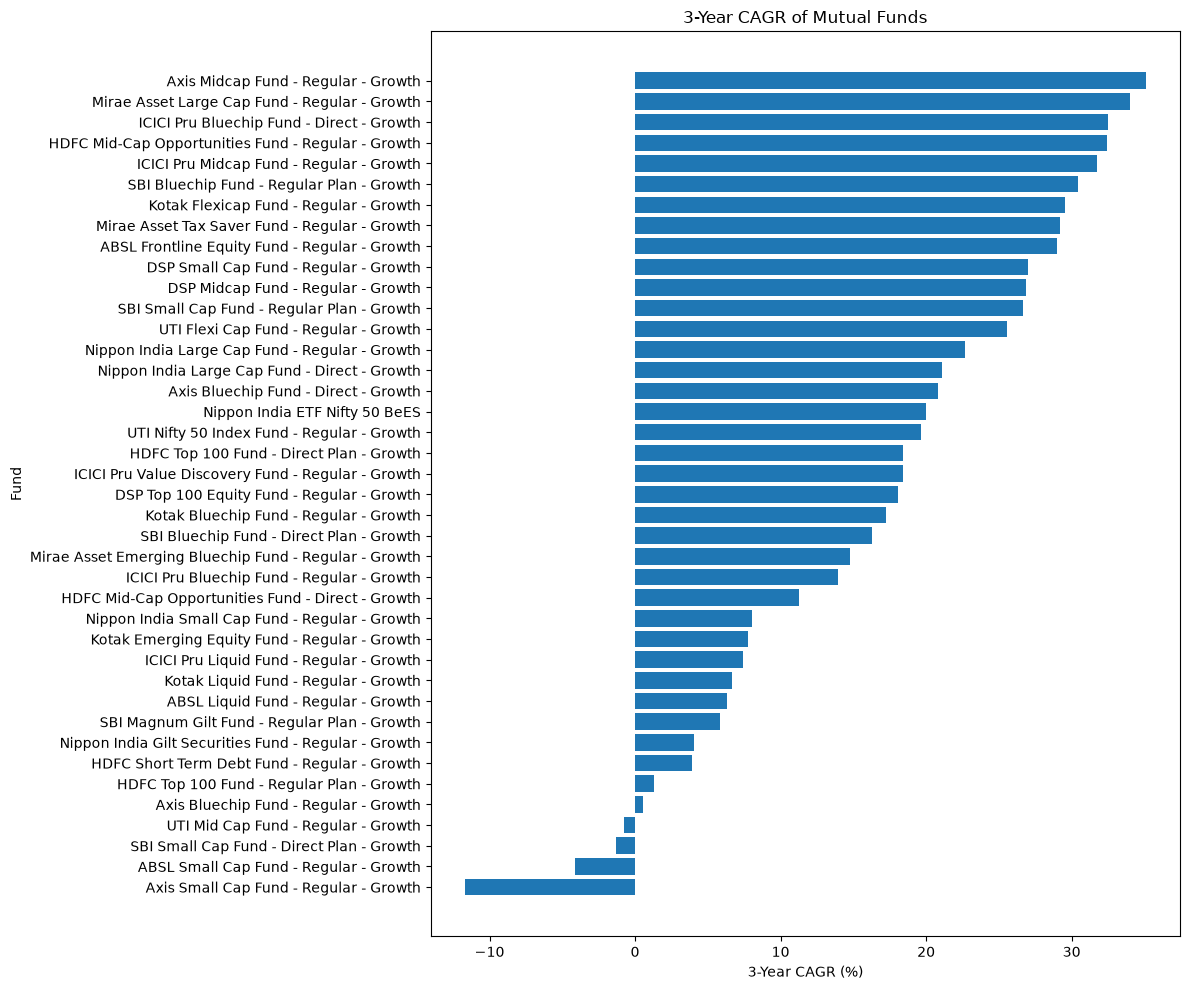

In [25]:
# Create a 3-year CAGR chart for all funds

chart_data = scorecard_final.sort_values(
    "cagr_3yr_pct",
    ascending=True
)

plt.figure(figsize=(12, 10))

plt.barh(
    chart_data["scheme_name"],
    chart_data["cagr_3yr_pct"]
)

plt.xlabel("3-Year CAGR (%)")
plt.ylabel("Fund")
plt.title("3-Year CAGR of Mutual Funds")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/day4_3yr_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# Recalculate CAGR using trading-day periods

cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").reset_index(drop=True)
    end_nav = group.iloc[-1]["nav"]

    result = {"amfi_code": amfi_code}

    for years in [1, 3, 5]:

        trading_days = 252 * years

        if len(group) > trading_days:

            start_nav = group.iloc[-(trading_days + 1)]["nav"]

            cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

            result[f"cagr_{years}yr_pct"] = cagr

        else:
            result[f"cagr_{years}yr_pct"] = np.nan

    cagr_results.append(result)

cagr = pd.DataFrame(cagr_results)

print("Trading-day CAGR calculated successfully!")
print("Funds:", len(cagr))
print("Missing 1Y CAGR:", cagr["cagr_1yr_pct"].isna().sum())
print("Missing 3Y CAGR:", cagr["cagr_3yr_pct"].isna().sum())
print("Missing 5Y CAGR:", cagr["cagr_5yr_pct"].isna().sum())

Trading-day CAGR calculated successfully!
Funds: 40
Missing 1Y CAGR: 0
Missing 3Y CAGR: 0
Missing 5Y CAGR: 40


In [27]:
# Update performance analysis with the corrected trading-day CAGR

performance_analysis = performance_analysis.drop(
    columns=["cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]
)

performance_analysis = performance_analysis.merge(
    cagr,
    on="amfi_code",
    how="left"
)

print("Performance analysis updated!")
print("Funds:", len(performance_analysis))
print("Missing 1Y CAGR:", performance_analysis["cagr_1yr_pct"].isna().sum())
print("Missing 3Y CAGR:", performance_analysis["cagr_3yr_pct"].isna().sum())
print("Missing 5Y CAGR:", performance_analysis["cagr_5yr_pct"].isna().sum())

Performance analysis updated!
Funds: 40
Missing 1Y CAGR: 0
Missing 3Y CAGR: 0
Missing 5Y CAGR: 40


In [28]:
# Recalculate fund score using corrected CAGR and Max Drawdown

def min_max_score(series):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(100, index=series.index)

    return ((series - min_value) / (max_value - min_value)) * 100


# Return score
performance_analysis["return_score"] = min_max_score(
    performance_analysis["cagr_3yr_pct"]
)

# Sharpe score
performance_analysis["sharpe_score"] = min_max_score(
    performance_analysis["sharpe_ratio_calculated"]
)

# Alpha score
performance_analysis["alpha_score"] = min_max_score(
    performance_analysis["alpha_pct"]
)

# Lower expense ratio = better score
performance_analysis["expense_score"] = (
    100 - min_max_score(performance_analysis["expense_ratio_pct"])
)

# Lower absolute drawdown = better score
performance_analysis["drawdown_score"] = (
    100 - min_max_score(performance_analysis["max_drawdown_pct"].abs())
)


# Final weighted score
performance_analysis["fund_score"] = (
    performance_analysis["return_score"] * 0.30
    + performance_analysis["sharpe_score"] * 0.25
    + performance_analysis["alpha_score"] * 0.20
    + performance_analysis["expense_score"] * 0.15
    + performance_analysis["drawdown_score"] * 0.10
).round(2)


print("Fund score recalculated successfully!")
print("Total funds:", len(performance_analysis))
print("Missing fund scores:", performance_analysis["fund_score"].isna().sum())
print(
    "Score range:",
    performance_analysis["fund_score"].min(),
    "to",
    performance_analysis["fund_score"].max()
)

Fund score recalculated successfully!
Total funds: 40
Missing fund scores: 0
Score range: 10.62 to 79.6


In [29]:
# Create the corrected final scorecard

scorecard = performance_analysis[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct",
        "sharpe_ratio_calculated",
        "sortino_ratio",
        "alpha_pct",
        "beta",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "fund_score"
    ]
].copy()

print("Corrected scorecard created!")
print("Rows:", len(scorecard))
print("Columns:", len(scorecard.columns))
print("Missing scores:", scorecard["fund_score"].isna().sum())

Corrected scorecard created!
Rows: 40
Columns: 13
Missing scores: 0


In [30]:
# Add benchmark tracking errors

scorecard_final = scorecard.merge(
    tracking_error,
    on="amfi_code",
    how="left"
)

print("Final performance table created!")
print("Total funds:", len(scorecard_final))
print(
    "Missing Nifty 50 tracking errors:",
    scorecard_final["tracking_error_nifty50_pct"].isna().sum()
)
print(
    "Missing Nifty 100 tracking errors:",
    scorecard_final["tracking_error_nifty100_pct"].isna().sum()
)

print("\nFinal columns:")
print(scorecard_final.columns.tolist())

Final performance table created!
Total funds: 40
Missing Nifty 50 tracking errors: 0
Missing Nifty 100 tracking errors: 0

Final columns:
['amfi_code', 'scheme_name', 'fund_house', 'cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct', 'sharpe_ratio_calculated', 'sortino_ratio', 'alpha_pct', 'beta', 'expense_ratio_pct', 'max_drawdown_pct', 'fund_score', 'tracking_error_nifty50_pct', 'tracking_error_nifty100_pct']


In [31]:
# Save corrected final performance table

output_path = "../reports/performance_analysis.csv"

scorecard_final.to_csv(
    output_path,
    index=False
)

print("Corrected performance analysis saved!")
print("Rows:", len(scorecard_final))
print("Columns:", len(scorecard_final.columns))
print("File:", output_path)

Corrected performance analysis saved!
Rows: 40
Columns: 15
File: ../reports/performance_analysis.csv


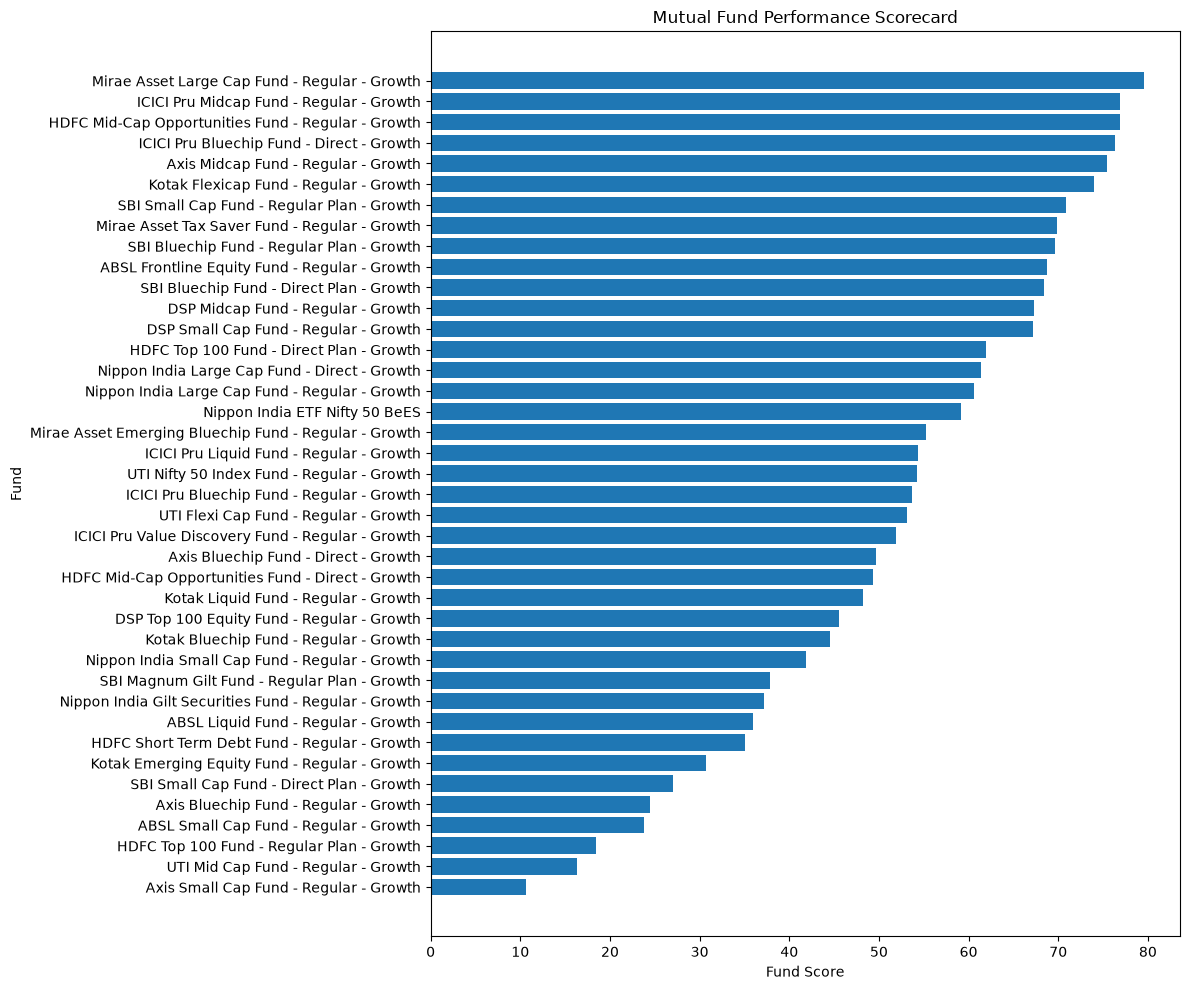

In [32]:
# Create Fund Score chart

chart_data = scorecard_final.sort_values(
    "fund_score",
    ascending=True
)

plt.figure(figsize=(12, 10))

plt.barh(
    chart_data["scheme_name"],
    chart_data["fund_score"]
)

plt.xlabel("Fund Score")
plt.ylabel("Fund")
plt.title("Mutual Fund Performance Scorecard")

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/day4_fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Final Day 4 validation

print("DAY 4 PERFORMANCE ANALYTICS CHECK")
print("=" * 50)

print("Total funds:", len(scorecard_final))
print("Total columns:", len(scorecard_final.columns))

print("\nMissing values:")
print(
    "1Y CAGR:",
    scorecard_final["cagr_1yr_pct"].isna().sum()
)
print(
    "3Y CAGR:",
    scorecard_final["cagr_3yr_pct"].isna().sum()
)
print(
    "5Y CAGR:",
    scorecard_final["cagr_5yr_pct"].isna().sum()
)
print(
    "Sharpe:",
    scorecard_final["sharpe_ratio_calculated"].isna().sum()
)
print(
    "Sortino:",
    scorecard_final["sortino_ratio"].isna().sum()
)
print(
    "Alpha:",
    scorecard_final["alpha_pct"].isna().sum()
)
print(
    "Beta:",
    scorecard_final["beta"].isna().sum()
)
print(
    "Fund Score:",
    scorecard_final["fund_score"].isna().sum()
)
print(
    "Nifty 50 Tracking Error:",
    scorecard_final["tracking_error_nifty50_pct"].isna().sum()
)
print(
    "Nifty 100 Tracking Error:",
    scorecard_final["tracking_error_nifty100_pct"].isna().sum()
)

print("\nDay 4 files:")
print("performance_analysis.csv")
print("day4_3yr_cagr.png")
print("day4_fund_scorecard.png")

DAY 4 PERFORMANCE ANALYTICS CHECK
Total funds: 40
Total columns: 15

Missing values:
1Y CAGR: 0
3Y CAGR: 0
5Y CAGR: 40
Sharpe: 0
Sortino: 0
Alpha: 0
Beta: 0
Fund Score: 0
Nifty 50 Tracking Error: 0
Nifty 100 Tracking Error: 0

Day 4 files:
performance_analysis.csv
day4_3yr_cagr.png
day4_fund_scorecard.png
